In [ ]:
# ==========================================
# 1: SETUP & MODEL LOADING
# ==========================================
!pip install open_clip_torch peft > /dev/null

import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler # AMP added for speed
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import (roc_auc_score, accuracy_score, confusion_matrix,
                             roc_curve, recall_score, f1_score, balanced_accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import open_clip
from PIL import Image
from peft import LoraConfig, get_peft_model, PeftModel

# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
base_path = "/content/drive/MyDrive/MrNet-v1/MRNet-v1.0"
axial_dir = base_path + "/merged_data/axial"
coronal_dir  = base_path + "/merged_data/coronal"
sagittal_dir = base_path + "/merged_data/sagittal"

train_df = pd.read_csv(base_path + "/train_split.csv")
val_df   = pd.read_csv(base_path + "/val_split.csv")
test_df  = pd.read_csv(base_path + "/test_split.csv")

# Load Base BioMedCLIP
print("Loading Base BioMedCLIP...")
model_name = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
clip_model, _, preprocess = open_clip.create_model_and_transforms(model_name)
clip_model = clip_model.to(device)
tokenizer = open_clip.get_tokenizer(model_name)
print("Loaded successfully!")

Mounted at /content/drive
Using device: cuda
Loading Base BioMedCLIP...
Loaded successfully!


In [ ]:
# ==========================================
#  2: DATASET & AUGMENTATIONS
# ==========================================
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
])

class LoRAMRNetDataset(Dataset):
    def __init__(self, df, plane_dir, is_train=False):
        self.df = df
        self.plane_dir = plane_dir
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = str(self.df.iloc[idx]["id"]).zfill(4)
        label = self.df.iloc[idx]["label"]

        vol = np.load(os.path.join(self.plane_dir, patient_id + ".npy"))
        vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)

        processed_slices = []
        for i in range(vol.shape[0]):
            slice_img = cv2.resize(vol[i], (224, 224))
            slice_img = (slice_img * 255).astype(np.uint8)
            slice_rgb = np.stack((slice_img,)*3, axis=-1)

            if self.is_train:
                slice_rgb = np.array(train_transform(slice_rgb))

            img_pil = Image.fromarray(slice_rgb)
            img_tensor = preprocess(img_pil)
            processed_slices.append(img_tensor)

        return torch.stack(processed_slices), torch.tensor(label, dtype=torch.long), patient_id

# Sampler for Class Imbalance
labels = train_df["label"].values
class_counts = np.bincount(labels)
sample_weights = (1. / class_counts)[labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

In [ ]:
# ==========================================
#  3: GATED ATTENTION, LoRA & TEXT FEATURES
# ==========================================
def get_ensembled_text_features(plane_name):
    prompts_healthy = [
        f"A normal {plane_name} MRI slice of the knee with an intact anterior cruciate ligament.",
        f"Healthy knee MRI showing a continuous ACL."
    ]
    prompts_tear = [
        f"A {plane_name} MRI slice of the knee showing a complete tear of the anterior cruciate ligament.",
        f"Ruptured anterior cruciate ligament with discontinuity."
    ]

    clip_model.eval()
    with torch.no_grad():
        tok_healthy = tokenizer(prompts_healthy).to(device)
        feat_healthy = clip_model.encode_text(tok_healthy).mean(dim=0, keepdim=True)

        tok_tear = tokenizer(prompts_tear).to(device)
        feat_tear = clip_model.encode_text(tok_tear).mean(dim=0, keepdim=True)

        text_features = torch.cat([feat_healthy, feat_tear], dim=0)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    return text_features

# NEW: Gated Attention Network (Replaces Mean Pooling)
class GatedAttention(nn.Module):
    def __init__(self, embed_dim=512, hidden_dim=256):
        super().__init__()
        self.attention_V = nn.Linear(embed_dim, hidden_dim)
        self.attention_U = nn.Linear(embed_dim, hidden_dim)
        self.attention_weights = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: [num_slices, embed_dim]
        a_v = torch.tanh(self.attention_V(x))
        a_u = torch.sigmoid(self.attention_U(x))
        w = self.attention_weights(a_v * a_u)       # [num_slices, 1]
        A = torch.softmax(w, dim=0)                 # [num_slices, 1]

        # Weighted sum of slices based on attention score
        M = torch.sum(A * x, dim=0, keepdim=True)   # [1, embed_dim]
        return M, A

class LoRABioMedCLIP(nn.Module):
    def __init__(self, lora_vision_encoder, base_clip_model, text_features):
        super().__init__()
        self.vision_encoder = lora_vision_encoder
        self.text_features = text_features.detach()
        self.logit_scale = base_clip_model.logit_scale

        # BioMedCLIP's embedding dimension is 512
        self.attention = GatedAttention(embed_dim=512, hidden_dim=256)

    def forward(self, image_volume):
        image_features = self.vision_encoder(image_volume)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Apply Gated Attention instead of Mean()
        patient_image_feature, attn_weights = self.attention(image_features)
        patient_image_feature = patient_image_feature / patient_image_feature.norm(dim=-1, keepdim=True)

        logit_scale = self.logit_scale.exp()
        logits = logit_scale * patient_image_feature @ self.text_features.t()
        return logits, attn_weights

In [ ]:
# ==========================================
# 4: LoRA + ATTENTION TRAINING LOOP (with AMP)
# ==========================================
def train_lora_model(planes, epochs=10):
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler() # AMP for faster training

    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["fc1", "fc2", "c_fc", "c_proj", "out_proj", "proj"],
        lora_dropout=0.1,
        bias="none"
    )

    for plane_name, plane_dir in planes:
        print(f"\n{'='*50}\n STARTING PEFT LoRA + GATED ATTN TUNING ({plane_name.upper()})\n{'='*50}")

        train_ds = LoRAMRNetDataset(train_df, plane_dir, is_train=True)
        val_ds   = LoRAMRNetDataset(val_df, plane_dir, is_train=False)

        train_loader = DataLoader(train_ds, batch_size=1, sampler=sampler, num_workers=2, pin_memory=True)
        val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

        text_feats = get_ensembled_text_features(plane_name)

        lora_vision_encoder = get_peft_model(clip_model.visual, lora_config)

        model = LoRABioMedCLIP(lora_vision_encoder, clip_model, text_feats).to(device)

        # Optimize BOTH LoRA adapters AND Gated Attention parameters
        trainable_params = list(filter(lambda p: p.requires_grad, model.vision_encoder.parameters())) + \
                           list(model.attention.parameters())

        optimizer = optim.AdamW(trainable_params, lr=2e-4, weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

        best_auc = 0.0

        for epoch in range(epochs):
            model.train()
            t_loss, t_correct, t_total = 0, 0, 0

            for imgs, lbls, _ in train_loader:
                imgs, lbls = imgs.squeeze(0).to(device), lbls.to(device)
                optimizer.zero_grad()

                # AMP Context Manager for speed
                with autocast('cuda'):
                    logits, _ = model(imgs)
                    loss = criterion(logits, lbls)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                t_loss += loss.item()
                preds = logits.argmax(dim=1)
                t_correct += (preds == lbls).sum().item()
                t_total += 1

            scheduler.step()

            model.eval()
            v_loss, v_correct, v_total, y_true, y_probs = 0, 0, 0, [], []
            with torch.no_grad():
                for imgs, lbls, _ in val_loader:
                    imgs, lbls = imgs.squeeze(0).to(device), lbls.to(device)

                    with autocast('cuda'):
                        logits, _ = model(imgs)
                        v_loss += criterion(logits, lbls).item()

                    prob_tear = logits.softmax(dim=-1)[0, 1].item()
                    y_true.append(lbls.item())
                    y_probs.append(prob_tear)

                    if logits.argmax(dim=1).item() == lbls.item(): v_correct += 1
                    v_total += 1

            auc = roc_auc_score(y_true, y_probs)

            print(f"Epoch [{epoch+1}/{epochs}] | LR: {scheduler.get_last_lr()[0]:.2e}")
            print(f"  [Train] Loss: {t_loss/t_total:.4f} | Acc: {(t_correct/t_total)*100:.2f}%")
            print(f"  [Val]   Loss: {v_loss/v_total:.4f} | Acc: {(v_correct/v_total)*100:.2f}% | AUC: {auc:.4f}")
            print("-" * 45)

            if auc > best_auc:
                best_auc = auc
                # Save both LoRA weights AND Attention weights
                model.vision_encoder.save_pretrained(os.path.join(base_path, f"lora_{plane_name}_best"))
                torch.save(model.attention.state_dict(), os.path.join(base_path, f"attn_{plane_name}_best.pth"))
                print("  => New Best Models Saved!")

        clip_model.visual = lora_vision_encoder.unload()

In [ ]:
target_planes = [("sagittal", sagittal_dir)]
train_lora_model(target_planes, epochs=10)


 STARTING PEFT LoRA + GATED ATTN TUNING (SAGITTAL)
Epoch [1/10] | LR: 1.95e-04
  [Train] Loss: 0.6109 | Acc: 70.29%
  [Val]   Loss: 0.8138 | Acc: 48.00% | AUC: 0.7875
---------------------------------------------
  => New Best Models Saved!
Epoch [2/10] | LR: 1.81e-04
  [Train] Loss: 0.5049 | Acc: 76.69%
  [Val]   Loss: 0.4736 | Acc: 78.40% | AUC: 0.8038
---------------------------------------------
  => New Best Models Saved!
Epoch [3/10] | LR: 1.59e-04
  [Train] Loss: 0.3947 | Acc: 83.66%
  [Val]   Loss: 0.4250 | Acc: 83.20% | AUC: 0.8289
---------------------------------------------
  => New Best Models Saved!
Epoch [4/10] | LR: 1.31e-04
  [Train] Loss: 0.3257 | Acc: 85.60%
  [Val]   Loss: 0.6289 | Acc: 78.40% | AUC: 0.8329
---------------------------------------------
  => New Best Models Saved!
Epoch [5/10] | LR: 1.01e-04
  [Train] Loss: 0.2103 | Acc: 92.23%
  [Val]   Loss: 0.4469 | Acc: 90.40% | AUC: 0.8498
---------------------------------------------
  => New Best Models Saved

Extracting LoRA+Attn features for SAGITTAL...
Extracting LoRA+Attn features for CORONAL...
Extracting LoRA+Attn features for AXIAL...
Optimal decision threshold found on VAL set: 0.2861
Extracting LoRA+Attn features for SAGITTAL...
Extracting LoRA+Attn features for CORONAL...
Extracting LoRA+Attn features for AXIAL...

TEST ENSEMBLE RESULTS
Accuracy:           0.8600
Balanced Accuracy:  0.8284
AUC:                0.8846
Sensitivity:        0.7736 (Recall for Tears)
Specificity:        0.8832 (Recall for Healthy)
F1-Score:           0.7009


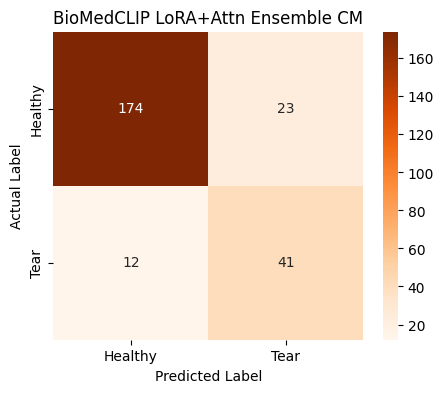

In [ ]:
# ==========================================
# 5: EVALUATION (AVOIDING DATA LEAKAGE)
# ==========================================
lora_explain_dicts = {"axial": {}, "coronal": {}, "sagittal": {}}

def extract_lora_probabilities(plane_name, plane_dir, df, is_test=False):
    print(f"Extracting LoRA+Attn features for {plane_name.upper()}...")
    text_feats = get_ensembled_text_features(plane_name)

    if hasattr(clip_model.visual, "peft_config"):
        delattr(clip_model.visual, "peft_config")

    adapter_path = os.path.join(base_path, f"lora_{plane_name}_best")
    attn_path = os.path.join(base_path, f"attn_{plane_name}_best.pth")

    lora_vision = PeftModel.from_pretrained(clip_model.visual, adapter_path)
    model = LoRABioMedCLIP(lora_vision, clip_model, text_feats).to(device)
    model.attention.load_state_dict(torch.load(attn_path))
    model.eval()

    dataset = LoRAMRNetDataset(df, plane_dir, is_train=False)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    patient_probs, labels = [], []

    with torch.no_grad():
        for imgs, lbl, p_id in loader:
            imgs = imgs.squeeze(0).to(device)
            lbl = lbl.item()
            p_id = p_id[0]

            with autocast('cuda'):
                logits, attn_weights = model(imgs)

            prob_tear = logits.softmax(dim=-1)[0, 1].cpu().numpy()
            patient_probs.append(prob_tear)
            labels.append(lbl)

            if is_test:
                # The attention network strictly tells us which slice it looked at!
                most_suspicious_idx = torch.argmax(attn_weights).item()
                lora_explain_dicts[plane_name][p_id] = most_suspicious_idx

    clip_model.visual = lora_vision.unload()
    return np.array(patient_probs), np.array(labels)

# 1. Gather VAL probabilities to FIND Threshold (No Data Leakage)
s_val_probs, y_val = extract_lora_probabilities("sagittal", sagittal_dir, val_df, is_test=False)
c_val_probs, _     = extract_lora_probabilities("coronal", coronal_dir, val_df, is_test=False)
a_val_probs, _     = extract_lora_probabilities("axial", axial_dir, val_df, is_test=False)

val_ensemble = (0.6 * s_val_probs) + (0.3 * c_val_probs) + (0.1 * a_val_probs)
fpr, tpr, thresholds = roc_curve(y_val, val_ensemble)
optimal_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal decision threshold found on VAL set: {optimal_threshold:.4f}")

# 2. Gather TEST probabilities to APPLY Threshold
s_probs, y_true = extract_lora_probabilities("sagittal", sagittal_dir, test_df, is_test=True)
c_probs, _      = extract_lora_probabilities("coronal", coronal_dir, test_df, is_test=True)
a_probs, _      = extract_lora_probabilities("axial", axial_dir, test_df, is_test=True)

test_ensemble = (0.6 * s_probs) + (0.3 * c_probs) + (0.1 * a_probs)
final_preds = (test_ensemble >= optimal_threshold).astype(int)

# Metrics
print(f"\n{'='*50}\nTEST ENSEMBLE RESULTS\n{'='*50}")
print(f"Accuracy:           {accuracy_score(y_true, final_preds):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_true, final_preds):.4f}")
print(f"AUC:                {roc_auc_score(y_true, test_ensemble):.4f}")
print(f"Sensitivity:        {recall_score(y_true, final_preds):.4f} (Recall for Tears)")
tn, fp, fn, tp = confusion_matrix(y_true, final_preds).ravel()
print(f"Specificity:        {tn / (tn + fp) if (tn + fp) > 0 else 0:.4f} (Recall for Healthy)")
print(f"F1-Score:           {f1_score(y_true, final_preds):.4f}")

cm = confusion_matrix(y_true, final_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Healthy', 'Tear'], yticklabels=['Healthy', 'Tear'])
plt.title("BioMedCLIP LoRA+Attn Ensemble CM")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Visualizing Tear Patient index: 3


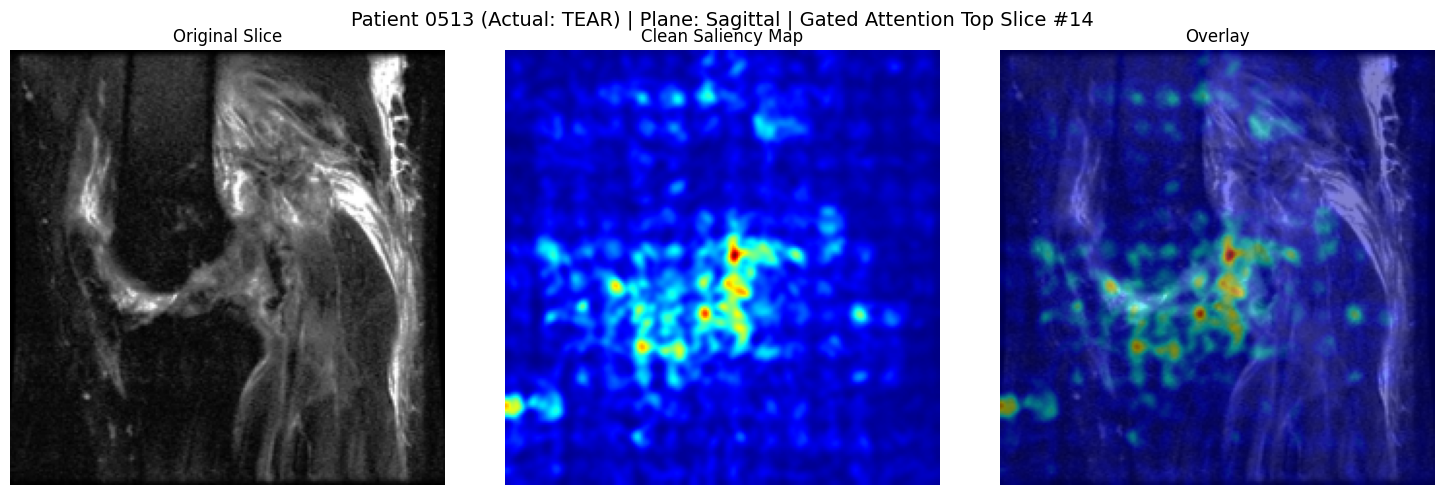

In [ ]:
# ==========================================
# 6: IMPROVED SALIENCY HEATMAPS
# ==========================================
def generate_clean_saliency_heatmap(img_tensor, plane_name, target_slice_idx):
    text_feats = get_ensembled_text_features(plane_name)
    tear_feature = text_feats[1:2]

    if hasattr(clip_model.visual, "peft_config"):
        delattr(clip_model.visual, "peft_config")

    adapter_path = os.path.join(base_path, f"lora_{plane_name}_best")
    lora_vision = PeftModel.from_pretrained(clip_model.visual, adapter_path)
    lora_vision.eval()
    lora_vision.zero_grad()

    single_slice = img_tensor[target_slice_idx:target_slice_idx+1].clone().detach().to(device)
    single_slice.requires_grad_()

    image_features = lora_vision(single_slice)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    logit_scale = clip_model.logit_scale.exp()
    similarity = (logit_scale * image_features @ tear_feature.t()).squeeze()
    similarity.backward()

    # IMPROVED: Guided-backprop style (ReLU to remove negative noise)
    saliency = single_slice.grad.data.squeeze().cpu().numpy()
    saliency = np.maximum(saliency, 0) # Drop negative gradients
    saliency = np.max(saliency, axis=0)

    saliency = cv2.GaussianBlur(saliency, (11, 11), 0)
    if saliency.max() != saliency.min():
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    else:
        saliency = np.zeros_like(saliency)

    heatmap = np.uint8(255 * saliency)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    clip_model.visual = lora_vision.unload()
    return heatmap_color

def visualize_lora_suspicious_slice(patient_idx=0, plane="sagittal"):
    patient_id = str(test_df.iloc[patient_idx]["id"]).zfill(4)
    true_label = test_df.iloc[patient_idx]["label"]

    # This is now dictated directly by the Gated Attention weights!
    target_slice_idx = lora_explain_dicts[plane][patient_id]
    plane_dir = sagittal_dir if plane == "sagittal" else (coronal_dir if plane == "coronal" else axial_dir)

    vol = np.load(os.path.join(plane_dir, patient_id + ".npy"))
    ds = LoRAMRNetDataset(test_df, plane_dir, is_train=False)
    img_tensor, _, _ = ds[patient_idx]

    heatmap_img = generate_clean_saliency_heatmap(img_tensor, plane, target_slice_idx)

    vol_norm = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)
    slice_img_resized = cv2.resize(vol_norm[target_slice_idx], (224, 224))
    slice_img_255 = (slice_img_resized * 255).astype(np.uint8)
    slice_rgb = np.stack((slice_img_255,)*3, axis=-1)

    overlay = cv2.addWeighted(slice_rgb, 0.5, heatmap_img, 0.5, 0)
    status = "TEAR" if true_label == 1 else "HEALTHY"

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Patient {patient_id} (Actual: {status}) | Plane: {plane.capitalize()} | Gated Attention Top Slice #{target_slice_idx}", fontsize=14)

    axes[0].imshow(slice_img_resized, cmap='gray'); axes[0].set_title("Original Slice"); axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(heatmap_img, cv2.COLOR_BGR2RGB)); axes[1].set_title("Clean Saliency Map"); axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); axes[2].set_title("Overlay"); axes[2].axis('off')
    plt.tight_layout()
    plt.show()

tear_patients = test_df[test_df['label'] == 1].index.tolist()
if tear_patients:
    print(f"Visualizing Tear Patient index: {tear_patients[0]}")
    visualize_lora_suspicious_slice(patient_idx=tear_patients[0], plane="sagittal")